In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/My Drive/

/content/drive/My Drive


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from tensorflow.keras.callbacks import EarlyStopping

 ### Load the CIFAR-10 dataset from TensorFlow Datasets

In [4]:
(train_ds, val_ds), info = tfds.load('cifar10', split=['train[:80%]', 'train[80%:]'], with_info=True,as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.A68H5X_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.A68H5X_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


Visualizing images from the training dataset:


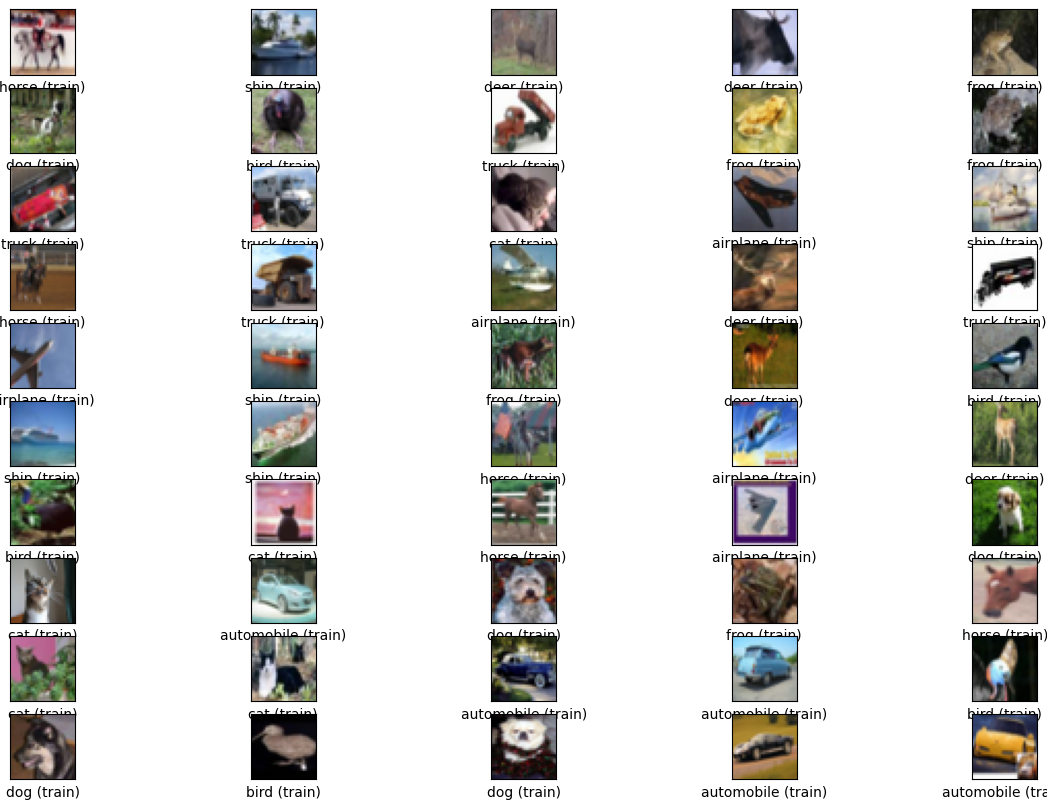

Visualizing images from the test dataset:


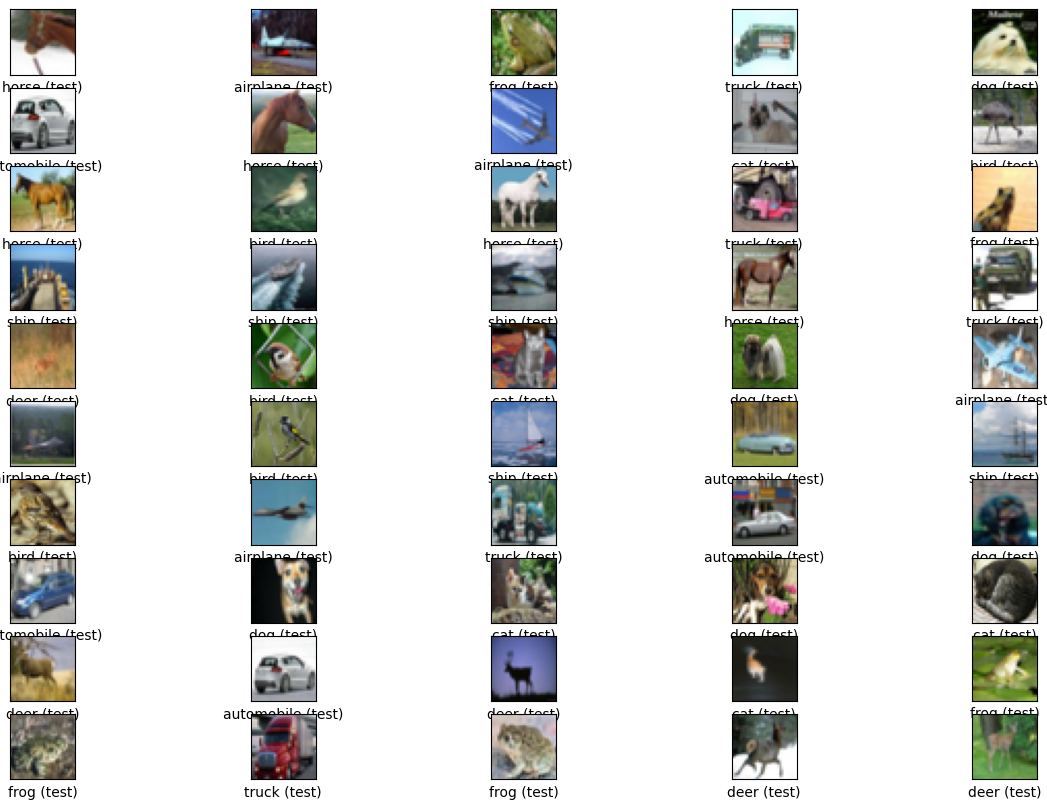

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import numpy as np

# Load the CIFAR-10 dataset
(train_ds, test_ds), info = tfds.load('cifar10', split=['train', 'test'], with_info=True, as_supervised=True)

# Define class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Function to display images
def display_images(dataset, dataset_type, num_images_per_class=5):
    plt.figure(figsize=(15, 10))
    class_count = {class_name: 0 for class_name in class_names}
    images_displayed = 0

    for image, label in dataset:
        label_index = label.numpy()
        class_name = class_names[label_index]
        if class_count[class_name] < num_images_per_class:
            plt.subplot(len(class_names), num_images_per_class, images_displayed + 1)
            plt.xticks([])
            plt.yticks([])
            plt.grid(False)
            plt.imshow(image.numpy())
            plt.xlabel(f'{class_name} ({dataset_type})')
            class_count[class_name] += 1
            images_displayed += 1
        if images_displayed >= len(class_names) * num_images_per_class:
            break
    plt.show()

# Visualize images from the training set
print("Visualizing images from the training dataset:")
display_images(train_ds, dataset_type='train')

# Visualize images from the test set
print("Visualizing images from the test dataset:")
display_images(test_ds, dataset_type='test')

### Preprocesses the data

In [6]:
data_augmentation = tf.keras.Sequential([
         layers.RandomFlip("horizontal_and_vertical"),
         layers.RandomRotation(0.2),
         layers.RandomZoom(0.1),  # Add random zoom
         layers.RandomContrast(0.2) # Add random contrast adjustments
     ])

def preprocess_data(image,label):
  image=tf.image.resize(image,[32,32])
  image = data_augmentation(image)
  image/=255.0
  return image,label

### Prepare datasets

In [7]:
batch_size=64
# train_ds = None # Placeholder, replace with your actual dataset # Removed this line
train_ds = train_ds.map(preprocess_data).shuffle(1000).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
# val_ds = None # Placeholder, replace with your actual dataset # Removed this line
val_ds = val_ds.map(preprocess_data).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

 ### Build a more complex CNN architecture

In [8]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 ### Compile the model

In [9]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

 ### Set up early stopping

In [10]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

### Train the model

In [ ]:
epochs = 30
history = model.fit(train_ds,validation_data=val_ds,epochs=epochs,callbacks=[early_stopping])

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 157s 194ms/step - accuracy: 0.2926 - loss: 2.0199 - val_accuracy: 0.3982 - val_loss: 1.6279
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 175ms/step - accuracy: 0.4132 - loss: 1.6333 - val_accuracy: 0.3515 - val_loss: 2.0349
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 176ms/step - accuracy: 0.4579 - loss: 1.5149 - val_accuracy: 0.4416 - val_loss: 1.6621
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 135s 171ms/step - accuracy: 0.4866 - loss: 1.4328 - val_accuracy: 0.4308 - val_loss: 1.6014
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 136s 173ms/step - accuracy: 0.5103 - loss: 1.3754 - val_accuracy: 0.5287 - val_loss: 1.3034
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 168ms/step - accuracy: 0.5362 - loss: 1.3209 - val_accuracy: 0.5292 - val_loss: 1.3387
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 144s 170ms/step - accuracy: 0.5495 - loss: 1.2773 - val_accuracy: 0.5681 - val_loss: 1.2173
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 134s 171ms/step - accuracy: 0.5633 -

###   Evaluate the model

In [ ]:
model.save('cifar10_model.h5')

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print(f'Validation accuracy: {accuracy:.2f}')

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.6958 - loss: 0.8515
Validation accuracy: 0.70


 ### Plot the training history

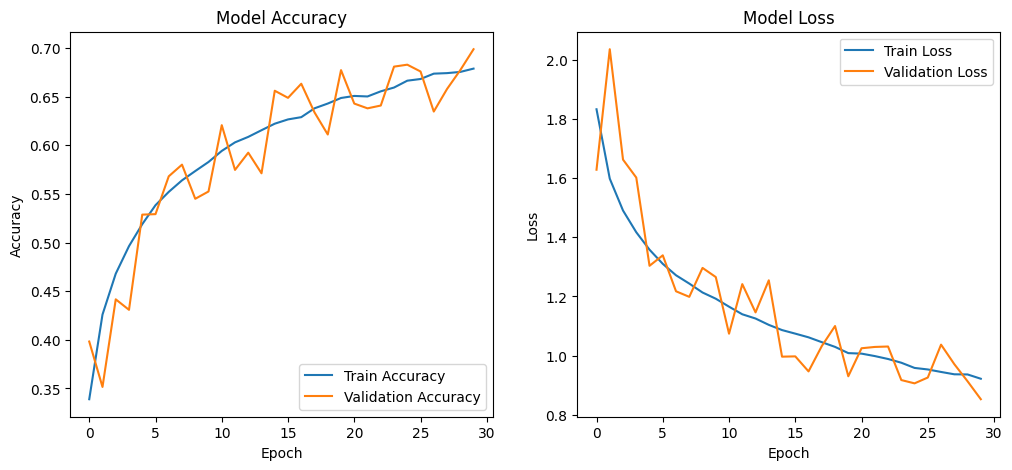

In [ ]:
def plot_history(history):
 plt.figure(figsize=(12, 5))
 plt.subplot(1, 2, 1)
 plt.plot(history.history['accuracy'], label='Train Accuracy')
 plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
 plt.title('Model Accuracy')
 plt.ylabel('Accuracy')
 plt.xlabel('Epoch')
 plt.legend(loc='lower right')

 plt.subplot(1, 2, 2)
 plt.plot(history.history['loss'], label='Train Loss')
 plt.plot(history.history['val_loss'], label='Validation Loss')
 plt.title('Model Loss')
 plt.ylabel('Loss')
 plt.xlabel('Epoch')
 plt.legend(loc='upper right')
 plt.show()
plot_history(history)